In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Phase 1: Feature Engineering and Baseline Modeling
**Capstone Project:** Population & Economic Dynamics in Puerto Rico

As outlined in our predictive framework, this notebook establishes the data foundation and baseline performance metrics. Before deploying complex non-linear models (like Random Forest), we must first clean the data, engineer domain-specific features, and train a straightforward baseline model (Ordinary Least Squares Linear Regression) to serve as our benchmark.

### The Predictive Pipeline


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for Feature Engineering & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plot style for professional visualizations
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully. Ready for data ingestion.")


Libraries loaded successfully. Ready for data ingestion.


## 1. Data Ingestion & Preprocessing
We begin by loading our consolidated master dataset, which includes Census population estimates, vital statistics (births/deaths), employer establishments, CDC Social Vulnerability Index (SVI) metrics, and historical hurricane tracks.


In [5]:
# Load the master profile
# Ensure the file is in your 'data/' directory or update the path accordingly
df = pd.read_csv('../data/puerto_rico_master_profile.csv')

# Standardize municipio names (stripping ' Municipio' suffix for cleaner charts)
df['municipio'] = df['municipio'].str.replace(' Municipio', '', case=False).str.strip()

# Sort by municipality and year for time-series operations
df = df.sort_values(by=['municipio', 'year']).reset_index(drop=True)

print(f"Loaded {df.shape[0]} rows across {df['municipio'].nunique()} municipalities.")
df.head()


Loaded 1170 rows across 78 municipalities.


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,unemployment_rate_pct,...,disability_pct,single_parent_pct,minority_pct,limited_english_pct,multi_unit_housing_pct,mobile_homes_pct,crowding_pct,no_vehicle_pct,group_quarters_count,pct_group_quarters
0,2010,Adjuntas,72001,19541,0,14834,99,6548,133,20.7,...,0.00,9.50,99.13,14.52,4.15,0.20,7.10,24.56,94,0.00
1,2011,Adjuntas,72001,19514,0,15000,107,6834,161,25.3,...,0.00,10.62,99.17,14.35,3.95,0.18,5.98,23.81,82,0.00
2,2012,Adjuntas,72001,19458,0,15081,80,7037,114,23.1,...,21.88,12.77,99.28,14.10,4.15,0.00,5.73,22.95,72,0.37
3,2013,Adjuntas,72001,19334,0,15087,79,7298,140,27.2,...,22.51,12.30,99.42,14.69,3.55,0.00,4.94,22.16,65,0.34
4,2014,Adjuntas,72001,19188,0,15080,88,7514,136,34.0,...,19.90,12.85,99.82,13.76,3.46,0.00,5.21,20.51,72,0.38


## 2. Feature Engineering & Dimensionality Reduction
Per our methodology, we engineer new features to better capture demographic momentum and economic shocks.

1. **Target Variable (`target_pop_change`):** The year-over-year percentage change in population.
2. **Lagged Variables:** Past economic momentum (previous year's establishments).
3. **Natural Change Rate:** Birth Rate minus Death Rate.
4. **Dimensionality Reduction (PCA):** The CDC SVI variables are highly collinear. We use PCA to compress them into a single "SVI_Composite_Score" to reduce noise.


In [6]:
# 1. Create the Target Variable: Year-over-Year Population % Change
df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100

# 2. Group SVI variables for Dimensionality Reduction
# These specific columns were identified in your master_profile.csv
svi_cols = [
    'poverty_rate_pct', 'unemployment_rate_pct', 'no_hs_diploma_pct', 
    'disability_pct', 'single_parent_pct', 'limited_english_pct',
    'multi_unit_housing_pct', 'crowding_pct', 'no_vehicle_pct'
]

# 3. Clean and Scale
df_clean = df.dropna(subset=['target_pop_change']).copy()
scaler = StandardScaler()
svi_scaled = scaler.fit_transform(df_clean[svi_cols])

# 4. Apply PCA to create a single 'Vulnerability Index' from the 9 variables
pca = PCA(n_components=1)
df_clean['vulnerability_index'] = pca.fit_transform(svi_scaled)

# 5. Final Feature Selection
# Note: We are using 'median_income_real' as the primary economic feature
features = ['vulnerability_index', 'median_income_real', 'labor_force_participation_pct', 'over_65_pct']
X = df_clean[features]
y = df_clean['target_pop_change']

print(f"PCA Variance Explained: {pca.explained_variance_ratio_[0]*100:.2f}%")
df_clean[['municipio', 'year', 'target_pop_change'] + features].head()


PCA Variance Explained: 29.28%


,municipio,year,target_pop_change,vulnerability_index,median_income_real,labor_force_participation_pct,over_65_pct
1,Adjuntas,2011,-0.138171,2.846551,18839.69,40.9,13.45
2,Adjuntas,2012,-0.286973,2.203857,18627.74,39.6,13.89
3,Adjuntas,2013,-0.637270,2.499764,16161.74,39.6,14.47
4,Adjuntas,2014,-0.755146,2.852010,14555.49,42.4,15.14
5,Adjuntas,2015,-1.177819,2.539457,14467.60,42.9,15.80


## 3. Baseline Model: Ordinary Least Squares (OLS)
We split our data into an 80/20 Training and Test set. We apply standard scaling to our features so that our regression coefficients are directly comparable. 

We use a simple Linear Regression model as our benchmark. This requires minimal tuning and establishes a performance "floor" that our future Random Forest model must exceed.


In [7]:
# 1. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the features (Crucial for regularized regression and comparing coefficients)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 3. Initialize and Train the Baseline Linear Regression Model
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

# Generate Predictions
y_pred_train = baseline_model.predict(X_train_scaled)
y_pred_test = baseline_model.predict(X_test_scaled)

print("Baseline Model Trained Successfully.")


Baseline Model Trained Successfully.


## 4. Evaluation & Next Steps
We evaluate our baseline model using **R-squared ($R^2$)** and **Root Mean Squared Error (RMSE)**. We also examine the feature coefficients to see which variables had the strongest linear relationship with population decline.


--- BASELINE MODEL PERFORMANCE ---
Test R-squared: 0.0126
Test RMSE:      2.1133 %
--------------------------------


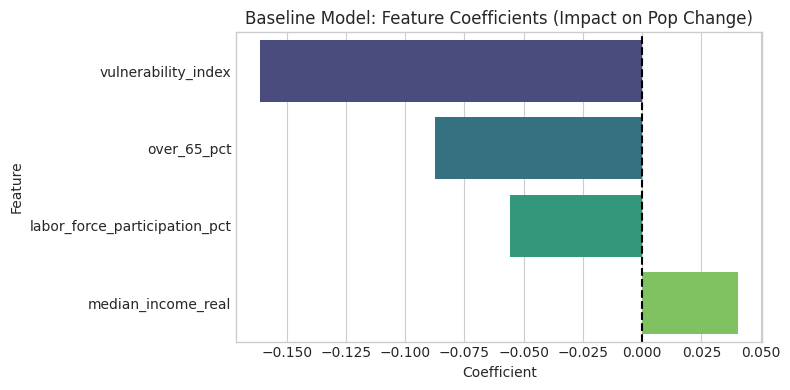

In [8]:
# Calculate Metrics
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("--- BASELINE MODEL PERFORMANCE ---")
print(f"Test R-squared: {r2_test:.4f}")
print(f"Test RMSE:      {rmse_test:.4f} %")
print("-" * 32)

# Plot Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': baseline_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Baseline Model: Feature Coefficients (Impact on Pop Change)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()
